# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Dataset
customer_id = list(range(1, 21))

daily_arrivals = [8, 12, 10, 15, 9,
                  13, 11, 14, 7, 16,
                  10, 12, 9, 15, 11,
                  13, 14, 8, 12, 10]

df = pd.DataFrame({
    "Customer_ID": customer_id,
    "Daily_Arrivals": daily_arrivals
})

## 1. Basic Statistics

In [2]:
# Mean
mean_val = np.mean(daily_arrivals)

# Population variance and Sample variance
population_variance = np.var(daily_arrivals)
sample_variance = np.var(daily_arrivals, ddof=1)

# Standard deviation
population_std = np.std(daily_arrivals)

print(f"Mean: {mean_val:.2f}")
print(f"Population Variance: {population_variance:.2f}")
print(f"Sample Variance: {sample_variance:.2f}")
print(f"Population Standard Deviation: {population_std:.2f}")

Mean: 11.45
Population Variance: 6.35
Sample Variance: 6.68
Population Standard Deviation: 2.52



### Compare and Difference Between Population Variance and Sample Variance

Population Variance: 6.35

Sample Variance: 6.68

Difference Between Population Variance and Sample Variance:

- **Population Variance** divides by `N`
- **Sample Variance** divides by `N - 1`




## 2. Random Number Generation

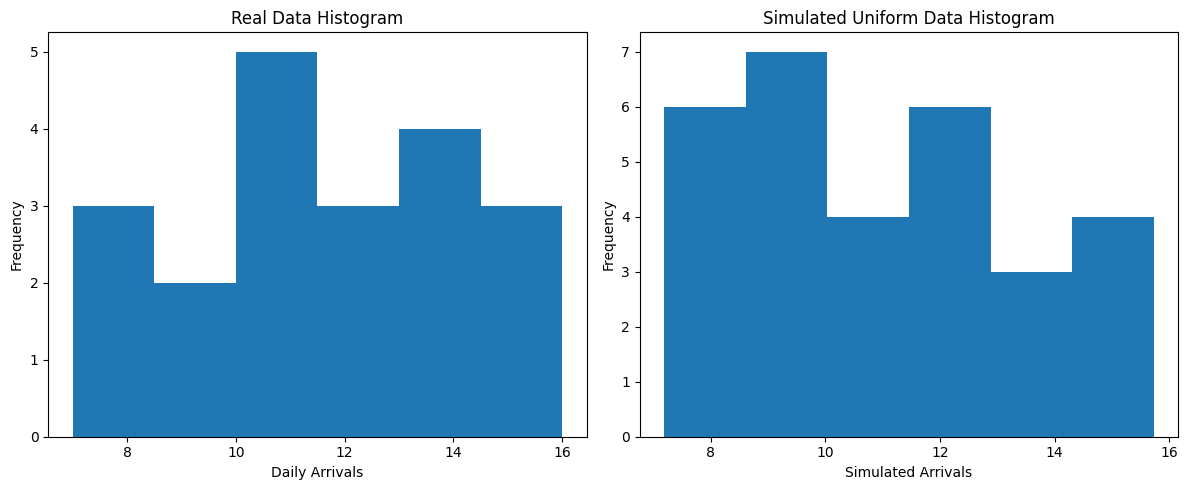

In [3]:
# Simulated dataset using uniform distribution
np.random.seed(42)

simulated_data = np.random.uniform(
    low=min(daily_arrivals),
    high=max(daily_arrivals),
    size=30
)

# Plot histograms
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(daily_arrivals, bins=6)
plt.title("Real Data Histogram")
plt.xlabel("Daily Arrivals")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(simulated_data, bins=6)
plt.title("Simulated Uniform Data Histogram")
plt.xlabel("Simulated Arrivals")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 3. Monte Carlo Simulation

In [4]:
# Monte Carlo simulation
num_samples = 100000

monte_carlo_samples = np.random.uniform(
    low=min(daily_arrivals),
    high=max(daily_arrivals),
    size=num_samples
)

# Probability of more than 15 arrivals
probability = np.mean(monte_carlo_samples > 15)

print(f"Estimated Probability of more than 15 arrivals: {probability:.4f}")

Estimated Probability of more than 15 arrivals: 0.1095


## 4. Hypothesis Testing


### Hypothesized Mean Formula


last 3 digits of Student ID: 026

So, Hypothesized Mean = ( 26 mod 10) + 10 = 16


In [5]:
hypothesized_mean = 16

# One-sample t-test
t_statistic, p_value = stats.ttest_1samp(daily_arrivals, hypothesized_mean)

print(f"Hypothesized Mean: {hypothesized_mean}")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Conclusion
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")


Hypothesized Mean: 16
T-statistic: -7.8720
P-value: 0.0000
Reject the null hypothesis.


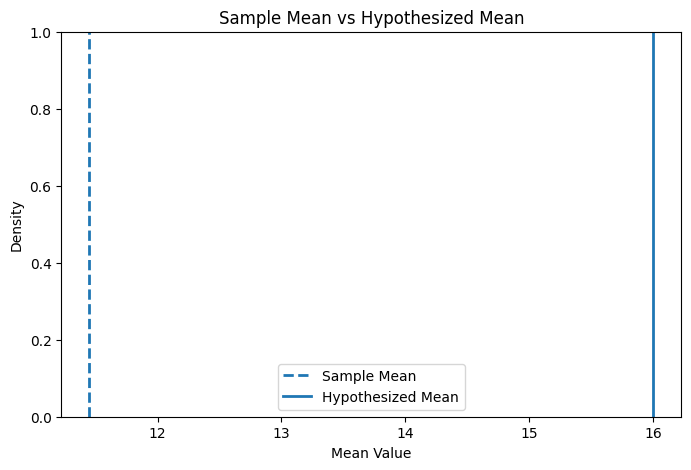

In [6]:
# Visualization
plt.figure(figsize=(8,5))

plt.axvline(np.mean(daily_arrivals), linestyle='--', linewidth=2, label='Sample Mean')
plt.axvline(hypothesized_mean, linestyle='-', linewidth=2, label='Hypothesized Mean')

plt.title("Sample Mean vs Hypothesized Mean")
plt.xlabel("Mean Value")
plt.ylabel("Density")
plt.legend()

plt.show()


### Unique interpretation of the result in context

Interpret the result based on my calculated p-value:

If p-value < 0.05:
  There is significant evidence that the actual mean daily customer arrival is different from the hypothesized mean.
If p-value >= 0.05:
  There is not enough evidence to conclude that the actual mean differs from the hypothesized mean.
